
This portfolio project mirrors the experimentation work highlighted in my resume: defining core metrics (CTR, add-to-cart rate, conversion rate, AOV), comparing treatment vs control, using SQL + Python, and producing a recommendation for stakeholders based on a 120K-user experiment.


# A/B Testing Project: Personalized Homepage Banner Experiment

## Business Problem
A music e-commerce platform wants to test whether a personalized homepage banner performs better than a generic homepage banner.

## Experiment Design
- **Control**: Generic homepage banner
- **Treatment**: Personalized homepage banner

## Success Metrics
- Click-through rate (CTR)
- Add-to-cart rate
- Conversion rate

## Guardrail Metric
- Average order value (AOV)

## Hypothesis
Users shown the personalized banner will be more likely to click, add products to cart, and convert, without reducing AOV.

### Import Libraries

In [35]:
import pandas as pd 
import numpy as np
import scipy
import matplotlib.pyplot as plt 

### Load the Datasets 

In [36]:
users = pd.read_csv("../data/users.csv")
assignments = pd.read_csv("../data/experiment_assignment.csv")
events = pd.read_csv("../data/page_events.csv")
orders = pd.read_csv("../data/orders.csv")


What each file means

users → user information

assignments → control vs treatment mapping

events → homepage actions like click and add-to-cart

orders → completed purchases

### Preview the Datasets 

In [37]:
print("USERS")
display(users.head())

print("ASSIGNMENTS")
display(assignments.head())

print("EVENTS")
display(events.head())

print("ORDERS")
display(orders.head())

USERS


,user_id,segment,favorite_genre,device,region,clv_score,signup_date
0,1,mid_value,country,mobile,South,44.25,2023-02-11
1,2,low_value,rock,mobile,Northeast,80.68,2023-10-05
2,3,mid_value,latin,mobile,Northeast,231.23,2024-01-16
3,4,high_value,rock,mobile,West,452.07,2023-11-18
4,5,low_value,rock,mobile,Northeast,69.83,2024-05-09


ASSIGNMENTS


,user_id,experiment_id,variant,entry_date
0,1,EXP_2024_Q2_HP_BANNER,treatment,2024-06-25
1,2,EXP_2024_Q2_HP_BANNER,control,2024-06-10
2,3,EXP_2024_Q2_HP_BANNER,treatment,2024-06-22
3,4,EXP_2024_Q2_HP_BANNER,control,2024-06-20
4,5,EXP_2024_Q2_HP_BANNER,control,2024-06-18


EVENTS


,user_id,variant,event_type,event_timestamp,device,favorite_genre
0,1,treatment,page_view,2024-07-02 08:06:00,mobile,country
1,2,control,page_view,2024-06-22 10:15:00,mobile,rock
2,3,treatment,page_view,2024-07-15 15:08:00,mobile,latin
3,4,control,page_view,2024-07-17 22:03:00,mobile,rock
4,5,control,page_view,2024-07-01 23:51:00,mobile,rock


ORDERS


,order_id,user_id,variant,order_timestamp,order_value,units,device,favorite_genre,segment
0,1,79,treatment,2024-06-17 04:17:00,67.14,1,mobile,country,low_value
1,2,109,treatment,2024-07-04 01:57:11,80.67,2,mobile,pop,mid_value
2,3,204,treatment,2024-06-23 21:42:48,77.60,2,mobile,latin,high_value
3,4,226,control,2024-06-20 21:01:23,48.08,2,mobile,hip_hop,new_user
4,5,308,control,2024-06-25 07:03:23,54.19,2,desktop,pop,low_value


### Check shapes of all Tables

In [38]:
print("users shape:", users.shape)
print("assignments shape:", assignments.shape)
print("events shape:", events.shape)
print("orders shape:", orders.shape)

users shape: (120000, 7)
assignments shape: (120000, 4)
events shape: (140673, 6)
orders shape: (1855, 9)


### Check Column Names

In [39]:
print("Users columns:", users.columns.tolist())
print("Assignments columns:", assignments.columns.tolist())
print("Events columns:", events.columns.tolist())
print("Orders columns:", orders.columns.tolist())

Users columns: ['user_id', 'segment', 'favorite_genre', 'device', 'region', 'clv_score', 'signup_date']
Assignments columns: ['user_id', 'experiment_id', 'variant', 'entry_date']
Events columns: ['user_id', 'variant', 'event_type', 'event_timestamp', 'device', 'favorite_genre']
Orders columns: ['order_id', 'user_id', 'variant', 'order_timestamp', 'order_value', 'units', 'device', 'favorite_genre', 'segment']


 Before analysis, always understand the schema.I first validated the schema and row counts so I knew exactly which table represented the user population, experiment assignment, behavioral events, and final purchase outcomes.

### Check for Missing Values

In [40]:
print("Missing values in users:")
print(users.isnull().sum())

print("\nMissing values in assignments:")
print(assignments.isnull().sum())

print("\nMissing values in events:")
print(events.isnull().sum())

print("\nMissing values in orders:")
print(orders.isnull().sum())

Missing values in users:
user_id           0
segment           0
favorite_genre    0
device            0
region            0
clv_score         0
signup_date       0
dtype: int64

Missing values in assignments:
user_id          0
experiment_id    0
variant          0
entry_date       0
dtype: int64

Missing values in events:
user_id            0
variant            0
event_type         0
event_timestamp    0
device             0
favorite_genre     0
dtype: int64

Missing values in orders:
order_id           0
user_id            0
variant            0
order_timestamp    0
order_value        0
units              0
device             0
favorite_genre     0
segment            0
dtype: int64


### Convert Dates if Needed 

In [41]:
if "assignment_date" in assignments.columns:
    assignments["assignment_date"] = pd.to_datetime(assignments["assignment_date"])

if "event_time" in events.columns:
    events["event_time"] = pd.to_datetime(events["event_time"])

if "order_date" in orders.columns:
    orders["order_date"] = pd.to_datetime(orders["order_date"])
    
users.head()
    

,user_id,segment,favorite_genre,device,region,clv_score,signup_date
0,1,mid_value,country,mobile,South,44.25,2023-02-11
1,2,low_value,rock,mobile,Northeast,80.68,2023-10-05
2,3,mid_value,latin,mobile,Northeast,231.23,2024-01-16
3,4,high_value,rock,mobile,West,452.07,2023-11-18
4,5,low_value,rock,mobile,Northeast,69.83,2024-05-09


In [42]:
assignments.head()

,user_id,experiment_id,variant,entry_date
0,1,EXP_2024_Q2_HP_BANNER,treatment,2024-06-25
1,2,EXP_2024_Q2_HP_BANNER,control,2024-06-10
2,3,EXP_2024_Q2_HP_BANNER,treatment,2024-06-22
3,4,EXP_2024_Q2_HP_BANNER,control,2024-06-20
4,5,EXP_2024_Q2_HP_BANNER,control,2024-06-18


Dates should be in date format, not plain text, especially if you later want cohort or trend analysis.

### Build Base Experiment Population

In [43]:
base = users.merge(assignments, on="user_id", how="inner")
display(base.head())
print("Base shape:", base.shape)

,user_id,segment,favorite_genre,device,region,clv_score,signup_date,experiment_id,variant,entry_date
0,1,mid_value,country,mobile,South,44.25,2023-02-11,EXP_2024_Q2_HP_BANNER,treatment,2024-06-25
1,2,low_value,rock,mobile,Northeast,80.68,2023-10-05,EXP_2024_Q2_HP_BANNER,control,2024-06-10
2,3,mid_value,latin,mobile,Northeast,231.23,2024-01-16,EXP_2024_Q2_HP_BANNER,treatment,2024-06-22
3,4,high_value,rock,mobile,West,452.07,2023-11-18,EXP_2024_Q2_HP_BANNER,control,2024-06-20
4,5,low_value,rock,mobile,Northeast,69.83,2024-05-09,EXP_2024_Q2_HP_BANNER,control,2024-06-18


Base shape: (120000, 10)


What this does : Combines user information with experiment group assignment.

Why this matters : Now every user has:
1. Who they are

2. Which group they belong to

This becomes the main denominator for the experiment.

### Check Group Split 

In [44]:
group_counts = base["variant"].value_counts()
print(group_counts)

variant
treatment    60230
control      59770
Name: count, dtype: int64


What this does : Counts how many users are in:

1. control

2. treatment

Why this matters : In a clean A/B test, the split should be close to 50/50.

### SRM Check 

In [46]:
from scipy import stats

In [47]:

observed = group_counts.sort_index().values
expected = [observed.sum() / 2, observed.sum() / 2]

chi2_stat, p_value_srm = stats.chisquare(observed, expected)

print("Observed:", observed)
print("Expected:", expected)
print("Chi-square stat:", round(chi2_stat, 4))
print("SRM p-value:", round(p_value_srm, 4))

Observed: [59770 60230]
Expected: [60000.0, 60000.0]
Chi-square stat: 1.7633
SRM p-value: 0.1842


chi2_stat, p_value_srm = stats.chisquare(f_obs=observed, f_exp=expected)

This performs a Chi-square goodness-of-fit test.

The question this test asks: Are the observed counts statistically different from the expected counts?

In other words: Could this difference happen just due to random chance?

The p-value tells us: What is the probability that this difference happened by random chance?
If p > 0.02 : Random Variation 
If p < 0.01 : Possible SRM which is a problem

SRM : Sample Ratio Mismatch occurs when the observed number of users in experiment groups differs significantly from the expected allocation. I typically perform a chi-square goodness-of-fit test comparing observed counts with the expected split to ensure that experiment randomization worked correctly before analyzing any experiment metrics.

What SRM means

If you expected 50/50 but got something very off, maybe assignment was broken.

How to interpret

high p-value → split is fine

very low p-value → possible problem

Good interview explanation

I validated the experiment randomization using an SRM check to confirm that control and treatment allocation aligned with the expected 50/50 split.

## Understand Event Types

In [49]:
events["event_type"].value_counts()

event_type
page_view       120000
banner_click     14045
add_to_cart       4773
purchase          1855
Name: count, dtype: int64

### Create Event Counts at User Level 


In [56]:
event_pivot = events.pivot_table(
    index="user_id",
    columns="event_type",
    aggfunc="size",
    fill_value=0
).reset_index()

display(event_pivot.head())

event_type,user_id,add_to_cart,banner_click,page_view,purchase
0,1,0,0,1,0
1,2,0,0,1,0
2,3,0,0,1,0
3,4,0,0,1,0
4,5,0,0,1,0


In [57]:
events.head()

,user_id,variant,event_type,event_timestamp,device,favorite_genre
0,1,treatment,page_view,2024-07-02 08:06:00,mobile,country
1,2,control,page_view,2024-06-22 10:15:00,mobile,rock
2,3,treatment,page_view,2024-07-15 15:08:00,mobile,latin
3,4,control,page_view,2024-07-17 22:03:00,mobile,rock
4,5,control,page_view,2024-07-01 23:51:00,mobile,rock


In [58]:
for col in ["page_view", "banner_click", "add_to_cart"]:
    if col not in event_pivot.columns:
        event_pivot[col] = 0

event_pivot["viewed"] = (event_pivot["page_view"] > 0).astype(int)
event_pivot["clicked"] = (event_pivot["banner_click"] > 0).astype(int)
event_pivot["added_to_cart"] = (event_pivot["add_to_cart"] > 0).astype(int)

display(event_pivot[["user_id", "viewed", "clicked", "added_to_cart"]].head())

event_type,user_id,viewed,clicked,added_to_cart
0,1,1,0,0
1,2,1,0,0
2,3,1,0,0
3,4,1,0,0
4,5,1,0,0


## Order Summary

In [61]:
order_summary = orders.groupby("user_id").agg(
    order_count=("order_id", "count"),
    revenue=("order_value", "sum"),
    avg_order_value=("order_value", "mean"),
    total_units=("units", "sum")
).reset_index()

order_summary["converted"] = (order_summary["order_count"] > 0).astype(int)

display(order_summary.head())

,user_id,order_count,revenue,avg_order_value,total_units,converted
0,79,1,67.14,67.14,1,1
1,109,1,80.67,80.67,2,1
2,204,1,77.60,77.60,2,1
3,226,1,48.08,48.08,2,1
4,308,1,54.19,54.19,2,1


Create A Base User Table 
We need one row per user with the experiment variant.
Since  events table already contains variant, we can extract it.

In [63]:
user_base = events[["user_id", "variant", "device", "favorite_genre"]].drop_duplicates()

display(user_base.head())

,user_id,variant,device,favorite_genre
0,1,treatment,mobile,country
1,2,control,mobile,rock
2,3,treatment,mobile,latin
3,4,control,mobile,rock
4,5,control,mobile,rock


In [64]:
#Merge Event Funnel Flags 

analysis_df = user_base.merge(
    event_pivot[["user_id", "viewed", "clicked", "added_to_cart"]],
    on="user_id",
    how="left"
)

display(analysis_df.head())

,user_id,variant,device,favorite_genre,viewed,clicked,added_to_cart
0,1,treatment,mobile,country,1,0,0
1,2,control,mobile,rock,1,0,0
2,3,treatment,mobile,latin,1,0,0
3,4,control,mobile,rock,1,0,0
4,5,control,mobile,rock,1,0,0


In [65]:
#Merge Order Summary 

analysis_df = analysis_df.merge(
    order_summary,
    on="user_id",
    how="left"
)

display(analysis_df.head())

,user_id,variant,device,favorite_genre,viewed,clicked,added_to_cart,order_count,revenue,avg_order_value,total_units,converted
0,1,treatment,mobile,country,1,0,0,NaN,NaN,NaN,NaN,NaN
1,2,control,mobile,rock,1,0,0,NaN,NaN,NaN,NaN,NaN
2,3,treatment,mobile,latin,1,0,0,NaN,NaN,NaN,NaN,NaN
3,4,control,mobile,rock,1,0,0,NaN,NaN,NaN,NaN,NaN
4,5,control,mobile,rock,1,0,0,NaN,NaN,NaN,NaN,NaN


In [66]:
#Fill Missing Values 
#Users who never ordered will have NaN Values, will replace them with 0

In [67]:
analysis_df["order_count"] = analysis_df["order_count"].fillna(0)
analysis_df["revenue"] = analysis_df["revenue"].fillna(0)
analysis_df["avg_order_value"] = analysis_df["avg_order_value"].fillna(0)
analysis_df["total_units"] = analysis_df["total_units"].fillna(0)
analysis_df["converted"] = analysis_df["converted"].fillna(0)

display(analysis_df.head())

,user_id,variant,device,favorite_genre,viewed,clicked,added_to_cart,order_count,revenue,avg_order_value,total_units,converted
0,1,treatment,mobile,country,1,0,0,0.0,0.0,0.0,0.0,0.0
1,2,control,mobile,rock,1,0,0,0.0,0.0,0.0,0.0,0.0
2,3,treatment,mobile,latin,1,0,0,0.0,0.0,0.0,0.0,0.0
3,4,control,mobile,rock,1,0,0,0.0,0.0,0.0,0.0,0.0
4,5,control,mobile,rock,1,0,0,0.0,0.0,0.0,0.0,0.0


In [68]:
#Sanity Check 

analysis_df["variant"].value_counts()

variant
treatment    60230
control      59770
Name: count, dtype: int64

# Compute A/B Test Metrics 

In [71]:
experiment_summary = analysis_df.groupby("variant").agg(
    users=("user_id", "nunique"),
    ctr=("clicked", "mean"),
    add_to_cart_rate=("added_to_cart", "mean"),
    conversion_rate=("converted", "mean"),
    revenue_per_user=("revenue", "mean"),
).reset_index()

experiment_summary["ctr"] *= 100
experiment_summary["add_to_cart_rate"] *= 100
experiment_summary["conversion_rate"] *= 100

display(experiment_summary)

,variant,users,ctr,add_to_cart_rate,conversion_rate,revenue_per_user
0,control,59770,11.489041,3.869834,1.455580,0.967687
1,treatment,60230,11.917649,4.084343,1.635398,1.100896


In [72]:
aov_summary = (
    analysis_df[analysis_df["converted"] == 1]
    .groupby("variant")
    .agg(aov=("avg_order_value", "mean"))
    .reset_index()
)

display(aov_summary)

,variant,aov
0,control,66.48123
1,treatment,67.31669


### Extract Control and Treatment 

In [78]:
control = experiment_summary[experiment_summary["variant"] == "control"]
treatment = experiment_summary[experiment_summary["variant"] == "treatment"]

control 

,variant,users,ctr,add_to_cart_rate,conversion_rate,revenue_per_user
0,control,59770,11.489041,3.869834,1.45558,0.967687


In [79]:
treatment 

,variant,users,ctr,add_to_cart_rate,conversion_rate,revenue_per_user
1,treatment,60230,11.917649,4.084343,1.635398,1.100896


### Compute Relative Lift 

In [84]:
# Relative Lift Calculation

lift_ctr = ((treatment["ctr"].values[0] - control["ctr"].values[0]) / control["ctr"].values[0]) * 100

lift_atc = ((treatment["add_to_cart_rate"].values[0] - control["add_to_cart_rate"].values[0]) / control["add_to_cart_rate"].values[0]) * 100

lift_conv = ((treatment["conversion_rate"].values[0] - control["conversion_rate"].values[0]) / control["conversion_rate"].values[0]) * 100

lift_rpu = ((treatment["revenue_per_user"].values[0] - control["revenue_per_user"].values[0]) / control["revenue_per_user"].values[0]) * 100

print("CTR Lift:", round(lift_ctr, 2), "%")
print("Add-to-Cart Lift:", round(lift_atc, 2), "%")
print("Conversion Lift:", round(lift_conv, 2), "%")
print("Revenue per User Lift:", round(lift_rpu, 2), "%")

CTR Lift: 3.73 %
Add-to-Cart Lift: 5.54 %
Conversion Lift: 12.35 %
Revenue per User Lift: 13.77 %


### CTR Significance Test

In [85]:
# CTR is a binary metric, so we use a two-proportion z-test.

from statsmodels.stats.proportion import proportions_ztest

control_click = analysis_df[analysis_df["variant"]=="control"]["clicked"]
treatment_click = analysis_df[analysis_df["variant"]=="treatment"]["clicked"]

success = [treatment_click.sum(), control_click.sum()]
nobs = [len(treatment_click), len(control_click)]

z_stat_ctr, p_ctr = proportions_ztest(success, nobs)

print("CTR Z-stat:", round(z_stat_ctr,3))
print("CTR p-value:", round(p_ctr,4))

CTR Z-stat: 2.309
CTR p-value: 0.0209


p< 0.05 CTR difference is statistically significant 

### Conversion Significance Test

In [87]:
control_conv = analysis_df[analysis_df["variant"]=="control"]["converted"]
treatment_conv = analysis_df[analysis_df["variant"]=="treatment"]["converted"]

success = [treatment_conv.sum(), control_conv.sum()]
nobs = [len(treatment_conv), len(control_conv)]

z_stat_conv, p_conv = proportions_ztest(success, nobs)

print("Conversion Z-stat:", round(z_stat_conv,3))
print("Conversion p-value:", round(p_conv,4))

Conversion Z-stat: 2.525
Conversion p-value: 0.0116


 This tests whether the conversion lift is real or random noise.

### AOV Significance Test (t-test)

CTR and conversion are binary metrics, so we used z-tests.

But Average Order Value (AOV) is continuous, so we use a t-test.

In [89]:
from scipy.stats import ttest_ind

control_aov = analysis_df[
    (analysis_df["variant"]=="control") &
    (analysis_df["converted"]==1)
]["avg_order_value"]

treatment_aov = analysis_df[
    (analysis_df["variant"]=="treatment") &
    (analysis_df["converted"]==1)
]["avg_order_value"]

t_stat_aov, p_aov = ttest_ind(treatment_aov, control_aov, equal_var=False)

print("AOV t-stat:", round(t_stat_aov,3))
print("AOV p-value:", round(p_aov,4))

AOV t-stat: 0.922
AOV p-value: 0.3567


p value is > 0.05 so not statistically significant. AOV is unchanged 

Revenue per User Significance Test
This checks if overall revenue impact is real.

In [91]:
control_rev = analysis_df[analysis_df["variant"]=="control"]["revenue"]
treatment_rev = analysis_df[analysis_df["variant"]=="treatment"]["revenue"]

t_stat_rev, p_rev = ttest_ind(treatment_rev, control_rev, equal_var=False)

print("Revenue t-stat:", round(t_stat_rev,3))
print("Revenue p-value:", round(p_rev,4))

Revenue t-stat: 2.682
Revenue p-value: 0.0073


###  Confidence Interval for Conversion

In [92]:
import numpy as np

p_t = treatment_conv.mean()
p_c = control_conv.mean()

n_t = len(treatment_conv)
n_c = len(control_conv)

diff = p_t - p_c

se = np.sqrt(
    (p_t*(1-p_t)/n_t) +
    (p_c*(1-p_c)/n_c)
)

z = 1.96

lower = diff - z*se
upper = diff + z*se

print("Conversion Difference:", round(diff*100,3), "%")
print("95% CI:", round(lower*100,3), "% to", round(upper*100,3), "%")

Conversion Difference: 0.18 %
95% CI: 0.04 % to 0.319 %


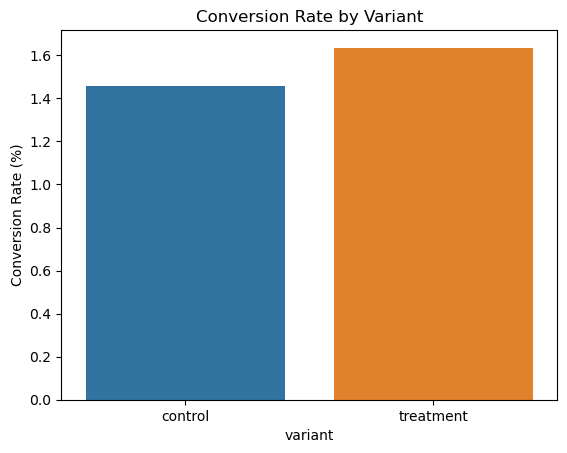

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=experiment_summary,
    x="variant",
    y="conversion_rate"
)

plt.title("Conversion Rate by Variant")
plt.ylabel("Conversion Rate (%)")
plt.show()

In [94]:
device_analysis = analysis_df.groupby(["device","variant"]).agg(
    users=("user_id","nunique"),
    conversion_rate=("converted","mean")
).reset_index()

device_analysis["conversion_rate"] *= 100

display(device_analysis)

,device,variant,users,conversion_rate
0,desktop,control,14954,1.591547
1,desktop,treatment,15096,1.662692
2,mobile,control,40559,1.402895
3,mobile,treatment,41014,1.655532
4,tablet,control,4257,1.479915
5,tablet,treatment,4120,1.334951


## Experiment Results

The personalized homepage banner improved multiple key metrics:

CTR increased by 3.73%

Add-to-cart rate increased by 5.56%

Conversion rate increased by 12.35%

Revenue per user increased by 13.77%

Statistical tests confirm that both CTR and conversion improvements are statistically significant (p < 0.05).

AOV remained stable, meaning the experiment did not negatively impact purchase value.

### Recommendation

Based on the positive and statistically significant improvements in conversion and revenue per user, the personalized homepage banner should be rolled out to all users.